 # Question:
 ## Is the amount of sleep gotten on school nights associated with age groups within teenagers?

 # My study
# This is an observational study where I can make claims between sleep and age of teenagers within the sample group provided in the survey from the American Statistical Association.

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("CensusAtSchool.csv")

In [8]:
df.head()

,Country,Region,DataYear,ClassGrade,Gender,Ageyears,Handed,Height_cm,Footlength_cm,Armspan_cm,...,Watching_TV_Hours,Paid_Work_Hours,Work_At_Home_Hours,Schoolwork_Pressure,Planned_Education_Level,Favorite_Music,Superpower,Preferred_Status,Role_Model_Type,Charity_Donation
0,USA,SC,2013,11,Male,17.0,Right-Handed,180,26,180,...,2,20,10,NaN,Graduate degree,Country,Invisibility,Rich,Relative,Health
1,USA,CA,2016,12,Female,17.0,Right-Handed,170,24,162.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,USA,WA,2025,12,Male,17.0,Right-Handed,182,26.5,176,...,0,0,3,Some,High school,Rock and roll,Freeze time,Healthy,Other,Other
3,USA,TN,2015,12,Male,17.0,Right-Handed,180,30,184,...,5,35,5,Very little,Graduate degree,Country,Fly,Happy,Friend,Other
4,USA,MA,2019,11,Male,16.0,Right-Handed,174.5,27,182,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 60 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country                           500 non-null    str    
 1   Region                            500 non-null    str    
 2   DataYear                          500 non-null    int64  
 3   ClassGrade                        500 non-null    int64  
 4   Gender                            497 non-null    str    
 5   Ageyears                          496 non-null    float64
 6   Handed                            492 non-null    str    
 7   Height_cm                         474 non-null    str    
 8   Footlength_cm                     459 non-null    str    
 9   Armspan_cm                        449 non-null    str    
 10  Languages_spoken                  489 non-null    str    
 11  Travel_to_School                  491 non-null    str    
 12  Travel_time_to_Scho

In [10]:
df['Sleep_Hours_Schoolnight'] = pd.to_numeric(
    df['Sleep_Hours_Schoolnight'], errors='coerce'
)
df['ClassGrade'] = pd.to_numeric(df['ClassGrade'], errors='coerce')

# Filter for teenagers (Grades 7 through 12)
df_teen = df[(df['ClassGrade'] >= 7) & (df['ClassGrade'] <= 12)].dropna(
    subset=['Sleep_Hours_Schoolnight']
)

# Create binary categories for a 2x2 table
df_teen['Grade_Level'] = df_teen['ClassGrade'].apply(
    lambda x: (
        'Middle School (Grades 7–8)' if x <= 8 else 'High School (Grades 9–12)'
    )
)
df_teen['Sleep_Status'] = df_teen['Sleep_Hours_Schoolnight'].apply(
    lambda x: (
        'Gets Recommended Sleep (8+ hrs)'
        if x >= 8
        else 'Gets Insufficient Sleep (< 8 hrs)'
    )
)

In [11]:
# Tab 1: Counts 2x2 Table with Totals
tab1_counts = pd.crosstab(
    df_teen['Grade_Level'],
    df_teen['Sleep_Status'],
    margins=True,
    margins_name='Totals',
)

In [12]:
print('--- TAB 1: COUNTS ---')
(tab1_counts)

--- TAB 1: COUNTS ---


Sleep_Status,Gets Insufficient Sleep (< 8 hrs),Gets Recommended Sleep (8+ hrs),Totals
Grade_Level,,,
High School (Grades 9–12),258,102,360
Middle School (Grades 7–8),15,25,40
Totals,273,127,400


In [13]:
# conditional relative frequency

## High school and middle school insufficent sleep status

In [14]:
badhs = (258/ 273)* 100
print(badhs)
badms = (15/273) * 100
print(badms)

94.5054945054945
5.4945054945054945


## High school and middle school recommended sleep status

In [15]:
goodhs = (102/127) * 100
print(goodhs)
goodms = (25/127)  * 100
print(goodms)

80.31496062992126
19.68503937007874


# Results: 
## 94.5% of students who get bad sleep are high schoolers while 5.5% of students who get bad sleep are middle schoolers
## 80% of good sleepers at high schools where 19.6% of good sleepers are middle schoolers

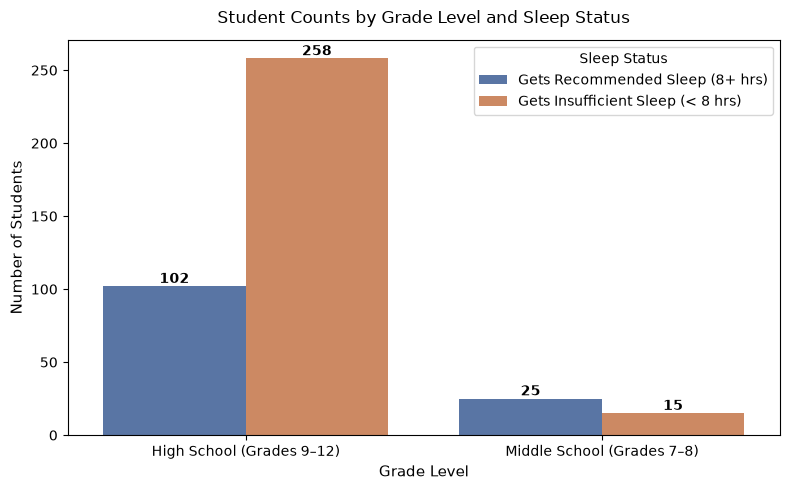

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(8, 5))

# Create grouped bar chart
ax = sns.countplot(
    data=df_teen,
    x='Grade_Level',
    hue='Sleep_Status',
    palette=['#4C72B0', '#DD8452'],
)

# Customizing labels and title
plt.title(
    'Student Counts by Grade Level and Sleep Status', fontsize=12, pad=12
)
plt.xlabel('Grade Level', fontsize=11)
plt.ylabel('Number of Students', fontsize=11)
plt.legend(title='Sleep Status')

# Display numerical counts above each bar
for p in ax.patches:
  height = int(p.get_height())
  if height > 0:
    ax.annotate(
        f'{height}',
        (p.get_x() + p.get_width() / 2.0, height),
        ha='center',
        va='center',
        xytext=(0, 5),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold',
    )

plt.tight_layout()
plt.show()

# Conclusion: The amount of sleep gotten on school nights is associated with the grade of a teenager. In the graph we can see the high schoolers significantly get less sleep than their middle schooler peers.
# Although there are unequal amounts of the sample age groups, when calculating the conditional relative frequency I found out that, 94.5% of bad sleepers are high schoolers of where the rest (5.5%) were middle schoolers. 
# We can also observe that more than half of 360 high schoolers have insufficient sleep compared to the rest of their high school peers compared to middle schoolers where the gap between good and bad sleepers was not that high(10 person difference from 25(bad) to 15(good))